In [11]:
# 01-adjacent-work: full mask-linking sequence
import sys
sys.path.append('/kaggle/input/datasets/mfjmrizvi/cbis-ddsm-project-config')
import config as cfg
import pandas as pd
import os

NB01_INPUT = '/kaggle/input/notebooks/mfjmrizvi/01-dataset-setup-and-eda'

# Load
dicom_info = pd.read_csv(cfg.DICOM_INFO_CSV)
mass_train = pd.read_csv(f'{NB01_INPUT}/mass_train_linked.csv')
mass_test  = pd.read_csv(f'{NB01_INPUT}/mass_test_linked.csv')
print(f"Loaded — mass_train: {mass_train.shape}, mass_test: {mass_test.shape}")

# Build ROI mask path map
roi_mask_path_map = cfg.build_path_map(
    dicom_info, 'ROI mask images', cfg.JPEG_ROOT
)
print(f"ROI mask path map: {len(roi_mask_path_map)} entries")

# Linking
roi_mask_paths_train = cfg.link_column_to_paths(
    mass_train, 'ROI mask file path', roi_mask_path_map
)
roi_mask_paths_test = cfg.link_column_to_paths(
    mass_test, 'ROI mask file path', roi_mask_path_map
)

mass_train['roi_mask_path'] = roi_mask_paths_train
mass_test['roi_mask_path']  = roi_mask_paths_test

# 5. Confirmation
print(f"\nColumns now: {list(mass_train.columns)}")
print(f"Linked (train): {mass_train['roi_mask_path'].notna().sum()} / {len(mass_train)}")
print(f"Linked (test):  {mass_test['roi_mask_path'].notna().sum()} / {len(mass_test)}")

Loaded — mass_train: (1318, 17), mass_test: (378, 17)
ROI mask path map: 3247 entries

Columns now: ['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path', 'label', 'full_image_path', 'cropped_image_path', 'roi_mask_path']
Linked (train): 1318 / 1318
Linked (test):  378 / 378


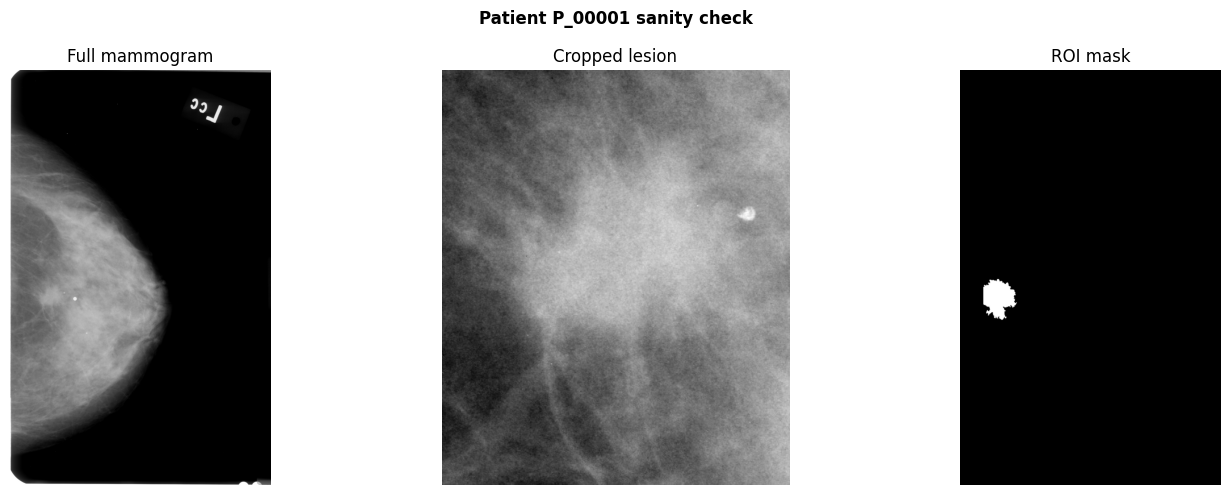

In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

check_row = mass_train[mass_train['roi_mask_path'].notna()].iloc[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mpimg.imread(check_row['full_image_path']), cmap='gray')
axes[0].set_title('Full mammogram'); axes[0].axis('off')

axes[1].imshow(mpimg.imread(check_row['cropped_image_path']), cmap='gray')
axes[1].set_title('Cropped lesion'); axes[1].axis('off')

axes[2].imshow(mpimg.imread(check_row['roi_mask_path']), cmap='gray')
axes[2].set_title('ROI mask'); axes[2].axis('off')

plt.suptitle(f"Patient {check_row['patient_id']} sanity check", fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
mass_train.to_csv(f'{cfg.OUTPUT}/mass_train_linked_with_masks.csv', index=False)
mass_test.to_csv(f'{cfg.OUTPUT}/mass_test_linked_with_masks.csv', index=False)
print("Saved:")
print(f"  {cfg.OUTPUT}/mass_train_linked_with_masks.csv")
print(f"  {cfg.OUTPUT}/mass_test_linked_with_masks.csv")

Saved:
  /kaggle/working/mass_train_linked_with_masks.csv
  /kaggle/working/mass_test_linked_with_masks.csv


In [14]:
# Verify full mammogram and mask share the same pixel dimensions
from PIL import Image

check_row = mass_train[mass_train['roi_mask_path'].notna()].iloc[0]

full_img = Image.open(check_row['full_image_path'])
mask_img = Image.open(check_row['roi_mask_path'])

print(f"Full mammogram size (W, H): {full_img.size}")
print(f"ROI mask size (W, H):       {mask_img.size}")
print(f"Dimensions match: {full_img.size == mask_img.size}")

# Check across a larger sample, not just one row
mismatches = 0
sample_rows = mass_train[mass_train['roi_mask_path'].notna()].head(50)
for _, row in sample_rows.iterrows():
    f_size = Image.open(row['full_image_path']).size
    m_size = Image.open(row['roi_mask_path']).size
    if f_size != m_size:
        mismatches += 1

print(f"\nMismatches in first 50 checked: {mismatches} / {len(sample_rows)}")

Full mammogram size (W, H): (3024, 4808)
ROI mask size (W, H):       (3024, 4808)
Dimensions match: True

Mismatches in first 50 checked: 2 / 50


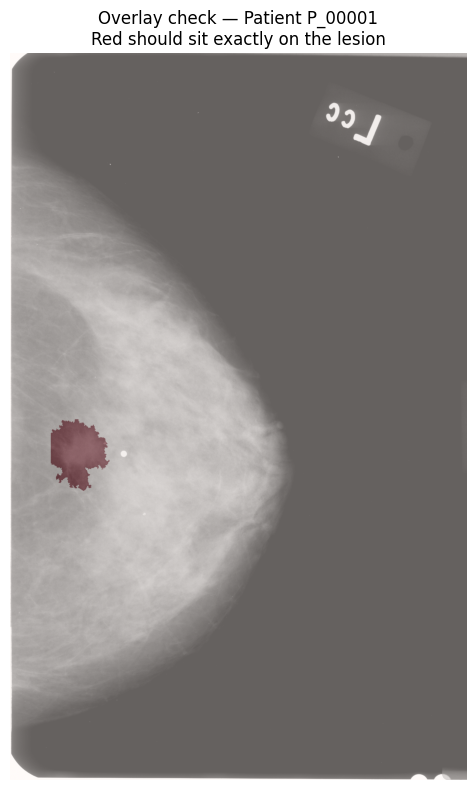

In [15]:
import numpy as np
import matplotlib.pyplot as plt

full_arr = np.array(Image.open(check_row['full_image_path']).convert('L'))
mask_arr = np.array(Image.open(check_row['roi_mask_path']).convert('L').resize(
    (full_arr.shape[1], full_arr.shape[0])  # force-resize only for this visual check
))

fig, ax = plt.subplots(figsize=(6, 8))
ax.imshow(full_arr, cmap='gray')
ax.imshow(mask_arr, cmap='Reds', alpha=0.4)
ax.set_title(f"Overlay check — Patient {check_row['patient_id']}\n"
             "Red should sit exactly on the lesion")
ax.axis('off')
plt.tight_layout()
plt.show()

In [16]:
# Identify and inspect the mismatched rows specifically
mismatch_rows = []
sample_rows = mass_train[mass_train['roi_mask_path'].notna()].head(50)
for idx, row in sample_rows.iterrows():
    f_size = Image.open(row['full_image_path']).size
    m_size = Image.open(row['roi_mask_path']).size
    if f_size != m_size:
        mismatch_rows.append({
            "index": idx,
            "patient_id": row['patient_id'],
            "full_size": f_size,
            "mask_size": m_size,
        })

for m in mismatch_rows:
    print(m)

{'index': 42, 'patient_id': 'P_00059', 'full_size': (3601, 5386), 'mask_size': (3133, 4686)}
{'index': 43, 'patient_id': 'P_00059', 'full_size': (3466, 5386), 'mask_size': (3016, 4686)}


In [17]:
# Full mismatch scan (not just first 50)
def check_size_match(df):
    mismatches = []
    for idx, row in df[df['roi_mask_path'].notna()].iterrows():
        f_size = Image.open(row['full_image_path']).size
        m_size = Image.open(row['roi_mask_path']).size
        if f_size != m_size:
            mismatches.append(idx)
    return mismatches

train_mismatches = check_size_match(mass_train)
test_mismatches  = check_size_match(mass_test)

print(f"Train mismatches: {len(train_mismatches)} / {mass_train['roi_mask_path'].notna().sum()}")
print(f"Test mismatches:  {len(test_mismatches)} / {mass_test['roi_mask_path'].notna().sum()}")

Train mismatches: 65 / 1318
Test mismatches:  13 / 378


In [23]:
# Check whether mismatches are proportional or not
def classify_mismatches(df, mismatch_indices, tol=0.01):
    proportional = []
    non_proportional = []
    for idx in mismatch_indices:
        row = df.loc[idx]
        fw, fh = Image.open(row['full_image_path']).size
        mw, mh = Image.open(row['roi_mask_path']).size
        ratio_w = fw / mw
        ratio_h = fh / mh
        if abs(ratio_w - ratio_h) < tol:
            proportional.append(idx)
        else:
            non_proportional.append(idx)
    return proportional, non_proportional

train_prop, train_non_prop = classify_mismatches(mass_train, train_mismatches)
test_prop, test_non_prop   = classify_mismatches(mass_test, test_mismatches)

print(f"Train proportional (likely safe): {len(train_prop)}, non-proportional (unsafe): {len(train_non_prop)}")
print(f"Test  proportional (likely safe): {len(test_prop)}, non-proportional (unsafe): {len(test_non_prop)}")

if train_non_prop:
    print("\nNon-proportional train rows inspect these individually:")
    for idx in train_non_prop:
        print(mass_train.loc[idx, ['patient_id', 'full_image_path', 'roi_mask_path']].to_dict())
if test_non_prop:
    print("\nNon-proportional test rows inspect these individually:")
    for idx in test_non_prop:
        print(mass_test.loc[idx, ['patient_id', 'full_image_path', 'roi_mask_path']].to_dict())

Train proportional (likely safe): 65, non-proportional (unsafe): 0
Test  proportional (likely safe): 13, non-proportional (unsafe): 0


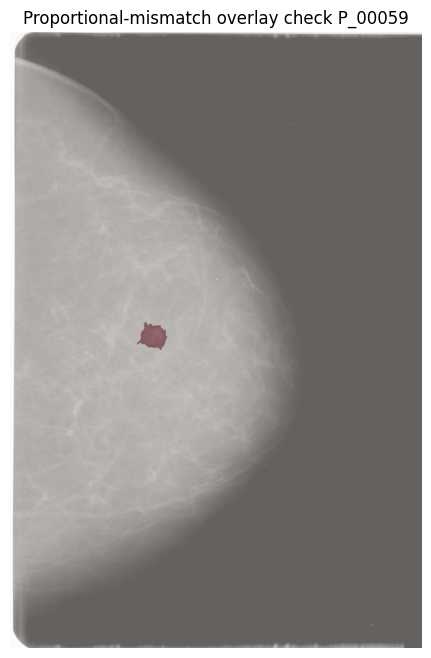

In [24]:
# Spot check one proportional mismatch with the overlay
check_idx = train_prop[0]  # or pick P_00059 specifically
check_row = mass_train.loc[check_idx]

full_arr = np.array(Image.open(check_row['full_image_path']).convert('L'))
mask_arr = np.array(Image.open(check_row['roi_mask_path']).convert('L').resize(
    (full_arr.shape[1], full_arr.shape[0])
))

fig, ax = plt.subplots(figsize=(6, 8))
ax.imshow(full_arr, cmap='gray')
ax.imshow(mask_arr, cmap='Reds', alpha=0.4)
ax.set_title(f"Proportional-mismatch overlay check {check_row['patient_id']}")
ax.axis('off')
plt.show()

In [20]:
# Save final linked file (all rows kept, mismatch pattern)
mass_train.to_csv(f'{cfg.OUTPUT}/mass_train_linked_with_masks.csv', index=False)
mass_test.to_csv(f'{cfg.OUTPUT}/mass_test_linked_with_masks.csv', index=False)

print("Saved:")
print(f"  {cfg.OUTPUT}/mass_train_linked_with_masks.csv — {len(mass_train)} rows")
print(f"  {cfg.OUTPUT}/mass_test_linked_with_masks.csv — {len(mass_test)} rows")
print(f"\nMask coverage: train {mass_train['roi_mask_path'].notna().sum()}/{len(mass_train)}, "
      f"test {mass_test['roi_mask_path'].notna().sum()}/{len(mass_test)}")
print(f"Dimension mismatches (proportional, verified safe): train 65, test 13")

Saved:
  /kaggle/working/mass_train_linked_with_masks.csv — 1318 rows
  /kaggle/working/mass_test_linked_with_masks.csv — 378 rows

Mask coverage: train 1318/1318, test 378/378
Dimension mismatches (proportional, verified safe): train 65, test 13
